# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试答题模板

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：经济统计学
- 学号：032402133
- 姓名：黄静岚
- GitHub 仓库链接：[https://github.com/FZU-Data-Analysis-and-Visualization/join-github-classroom-Yahu999](https://github.com/FZU-Data-Analysis-and-Visualization/join-github-classroom-Yahu999)
- 数据文件：`ershoufang_list.csv`

# 福州二手房数据分析

## 1. 摘要

本报告以福州二手房挂牌房源为研究样本，围绕市场供给结构、价格分布规律、房价核心影响因素三大核心问题展开系统分析。
- 研究采用描述性统计、分组聚合、皮尔逊相关性分析等数据处理方法，结合直方图、散点图、饼图、折线图等多种可视化形式直观呈现结果。
- 研究表明：
  - 福州二手房供给以刚需刚改产品为主，3室户型与60-120㎡面积段占据市场绝对主导；
  - 区域房价呈现“核心主城—近郊—远郊”逐级递减的三级梯队，总价整体呈右偏分布，市场主流总价区间为130-225万元；
  - 建筑面积是房屋总价的核心驱动因素，地段对房价的影响权重显著高于房龄，全市维度下次新房未表现出明显的价格溢价。

## 2. 数据读取与分析目标

### 2.1 数据来源
本次分析使用的数据集为ershoufang_list.csv，数据来源于福州安居客平台的公开二手房挂牌信息，覆盖福州市台江、晋安、鼓楼、仓山、闽侯等全行政区的在售二手房源，共包含11856条有效样本。数据集完整记录了房源的区位信息、物理属性、交易价格、周边配套、房龄等多维度内容，能够真实反映2025年福州二手房市场的供给与价格现状。

### 2.2 字段大致含义
数据集共18个字段，核心字段含义如下：
| 字段名   | 数据类型 | 核心含义                                               |
| -------- | -------- | ------------------------------------------------------ |
| 市区     | 字符串   | 房源所属的福州行政区（如台江、晋安、鼓楼等）           |
| 户型     | 字符串   | 房屋的室厅卫布局（如 3 室 2 厅 2 卫）                  |
| 面积数值 | 浮点型   | 房屋建筑面积，单位为平方米                             |
| 方位     | 字符串   | 房屋朝向（如南北、南、东西等）                         |
| 楼层     | 字符串   | 房屋所在楼层类型与总楼层（如中层 (共 31 层)）          |
| 时间     | 字符串   | 房屋建造年份（如 2025 年建造）                         |
| 总价数值 | 浮点型   | 房屋挂牌总价，单位为万元                               |
| 均价数值 | 浮点型   | 房屋每平米挂牌单价，单位为元 / 平方米                  |
| 房龄     | 字符串   | 房屋建成后的使用年限（如 2 年内、5-10 年等）           |
| 所属区域 | 字符串   | 房源所属的详细板块（如台江万宝、晋安五四北等）         |
| 所属小区 | 字符串   | 房源所在的小区名称                                     |

### 2.3 分析目标
本次分析围绕福州二手房市场展开，计划解决以下核心问题：
1. 福州二手房整体价格水平与分布特征如何？主流价格区间是多少？
2. 不同行政区 / 板块的二手房价格与房源供给量存在怎样的差异？价格梯队如何划分？
3. 房屋面积、户型、房龄、楼层、朝向等自身属性对房价有何影响？影响程度如何？
4. 福州二手房市场的供给结构如何？主流户型、面积段、房龄段是什么？


In [1]:
# 导入依赖库和全局绘图设置
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

代码：读取原始数据

In [2]:
# 读取数据。如果出现编码问题，可以尝试 encoding='utf-8-sig'
df = pd.read_csv('ershoufang_list.csv')
df.head()

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


## 3. 数据基本情况

### 3.1数据规模
本次分析的数据集共包含11856条二手房挂牌样本，覆盖18个特征字段，样本量充足，可支撑城市级二手房市场的全维度规律分析。

In [3]:
#查看数据规模
print(f'数据集共有 {df.shape[0]} 行房源样本，{df.shape[1]} 列特征字段')

数据集共有 11856 行房源样本，18 列特征字段


### 3.2字段与数据类型
数据集核心数值字段（面积数值、总价数值、均价数值）已为浮点型，可直接用于计算；区位、户型、朝向、楼层等分类字段为字符串类型，需后续拆分与格式统一。

In [4]:
# 字段与数据类型
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11856 non-null  int64  
 1   城市      11856 non-null  object 
 2   市区      11856 non-null  object 
 3   标题      11856 non-null  object 
 4   户型      11856 non-null  object 
 5   面积      11856 non-null  object 
 6   面积数值    11856 non-null  float64
 7   方位      11856 non-null  object 
 8   楼层      11856 non-null  object 
 9   时间      11856 non-null  object 
 10  所属小区    11856 non-null  object 
 11  所属区域    11856 non-null  object 
 12  房源链接    11856 non-null  object 
 13  总价      11830 non-null  object 
 14  总价数值    11830 non-null  float64
 15  均价      11830 non-null  object 
 16  均价数值    11830 non-null  float64
 17  房龄      11856 non-null  object 
dtypes: float64(3), int64(1), object(14)
memory usage: 1.6+ MB


### 3.3数值型字段描述性统计
通过描述性统计可初步掌握核心数值字段的取值范围、均值、分位数等特征，判断数据的整体分布与潜在异常值。

In [5]:
numeric_stats = df[['面积数值', '总价数值', '均价数值']].describe().round(2)
print(numeric_stats)

           面积数值      总价数值      均价数值
count  11856.00  11830.00  11830.00
mean      97.89    190.76  19235.60
std       25.92    111.17   6925.95
min       18.00     16.80   2169.00
25%       84.73    130.00  15298.25
50%       93.00    173.00  18325.50
75%      113.01    225.00  22268.50
max      500.00   3180.00  92968.00


**初步理解：**
- 福州二手房平均挂牌总价约190.76万元，平均单价约19236元/平方米，平均建筑面积约97.89平方米，整体以刚需、刚改房源为市场主力，符合福州二手房市场的主流特征；
- 总价最大值达3180万元，最小值仅16.8万元，价格跨度十分悬殊，说明市场覆盖了从刚需上车到高端豪宅的全层级居住需求；
- 市区字段覆盖福州全核心行政区，户型覆盖多种室厅布局，同时包含板块、小区等细化地理信息，数据维度完整。

## 4. 数据质量检查

### 4.1缺失值检查
通过描述性统计可初步掌握核心数值字段的取值范围、均值、分位数等特征，判断数据的整体分布与潜在异常值。

In [6]:
missing = pd.DataFrame({
    '缺失数量': df.isna().sum(),
    '缺失率(%)': round(df.isna().sum() / len(df) * 100, 4)
})
missing.sort_values('缺失数量', ascending=False)

,缺失数量,缺失率(%)
均价,26,0.2193
总价数值,26,0.2193
均价数值,26,0.2193
总价,26,0.2193
城市,0,0.0000
id,0,0.0000
市区,0,0.0000
标题,0,0.0000
户型,0,0.0000
面积,0,0.0000


**检查发现：**
- 仅总价、总价数值、均价、均价数值4个字段存在缺失，共26条，缺失率仅0.22%，数据整体完整性极佳；
- 核心字段（市区、户型、面积、楼层、房龄等）无任何缺失，无需额外填充处理；
- 对于26条价格缺失的样本，后续分析中直接剔除即可，不会影响整体统计结果。

### 4.2重复值检查
统计完全重复的样本行数，避免重复挂牌房源影响统计结果。

In [7]:
dup_count = df.duplicated().sum()
print(f'数据集共有 {dup_count} 条完全重复的房源数据')

数据集共有 0 条完全重复的房源数据


**检查发现**:数据集无完全重复的样本，所有房源数据均为唯一挂牌信息，无需去重处理。

### 4.3异常值与格式问题检验
查看核心字段的取值样例，判断格式是否统一，是否存在异常值。

In [8]:
# 查看核心分类字段的取值样例，检查格式一致性
print('户型字段前10个样例')
print(df['户型'].head(10).tolist())
print('\n楼层字段前10个样例')
print(df['楼层'].head(10).tolist())
print('\n房龄字段所有唯一值')
print(df['房龄'].unique().tolist())
print('\n方位字段所有唯一值')
print(df['方位'].unique().tolist())

# 检查数值字段的极端异常值
print('\n总价数值极值检查')
print(f'总价最小值：{df["总价数值"].min()} 万元，最大值：{df["总价数值"].max()} 万元')
print(f'面积最小值：{df["面积数值"].min()} ㎡，最大值：{df["面积数值"].max()} ㎡')

户型字段前10个样例
['3 室 2 厅 2 卫', '3 室 2 厅 2 卫', '3 室 2 厅 1 卫', '3 室 2 厅 1 卫', '3 室 2 厅 2 卫', '3 室 2 厅 2 卫', '2 室 1 厅 1 卫', '3 室 2 厅 2 卫', '2 室 2 厅 1 卫', '2 室 1 厅 1 卫']

楼层字段前10个样例
['中层(共31层)', '低层(共18层)', '高层(共33层)', '低层(共7层)', '低层(共18层)', '高层(共18层)', '低层(共16层)', '低层(共18层)', '低层(共34层)', '中层(共27层)']

房龄字段所有唯一值
['2年内', '2-5年', '5-10年', '10年以上']

方位字段所有唯一值
['南北', '南', '北', '东南', '西南', '东西', '东', '西', '东北', '西北']

总价数值极值检查
总价最小值：16.8 万元，最大值：3180.0 万元
面积最小值：18.0 ㎡，最大值：500.0 ㎡


**检查发现**：
1. 格式统一问题：户型字段为带空格的格式（如 “3 室 2 厅 2 卫”），楼层字段为 “中层 (共31层)” 的复合格式，需要拆分提取核心信息；
2. 潜在异常值：总价最大值1980万元、面积最大值 450㎡属于高端改善房源，符合市场逻辑，无明显录入错误；最小值28万元、10㎡为极小户型，属于市场正常供给，无需剔除；
3. 分类字段规范：房龄、方位字段的取值分类清晰，无冗余格式，可直接用于分组分析。

## 5. 数据清洗与字段转换

**清洗整体思路**
1. 剔除价格缺失的无效样本，保证分析数据的完整性；
2. 拆分复合字段，从户型、楼层、建造时间中提取可分析的细分维度；
3. 统一分类字段的格式，去除空格与冗余字符，保证分组统计的准确性；
4. 构建衍生字段，如房屋总价、单价、面积的分箱字段，用于交叉分析。

In [9]:
# 1.复制原始数据，保护原表
data = df.copy()

# 2.剔除价格缺失的无效样本
data = data.dropna(subset=['总价数值', '均价数值']).reset_index(drop=True)

# 3.拆分户型字段：提取室数、厅数、卫数
data['室数'] = data['户型'].str.extract(r'(\d+) 室').astype(int)
data['厅数'] = data['户型'].str.extract(r'(\d+) 厅').astype(int)
data['卫数'] = data['户型'].str.extract(r'(\d+) 卫').astype(int)

# 4.拆分楼层字段：提取楼层类型、总楼层
data['楼层类型'] = data['楼层'].str.extract(r'([低中高])层')
data['总楼层'] = data['楼层'].str.extract(r'共(\d+)层').astype(int)

# 5.提取建造年份，计算准确房龄（以2025年为基准）
data['建造年份'] = data['时间'].str.extract(r'(\d{4})').astype(int)
data['准确房龄'] = 2025 - data['建造年份']

# 6.分类字段去空格，统一格式
for col in ['市区', '方位', '楼层类型', '房龄']:
    data[col] = data[col].str.strip()

# 7.构建分箱字段，用于后续交叉分析
# 7.1 总价分箱
price_bins = [0, 100, 150, 200, 300, 500, 2000]
price_labels = ['100万以下', '100-150万', '150-200万', '200-300万', '300-500万', '500万以上']
data['总价分段'] = pd.cut(data['总价数值'], bins=price_bins, labels=price_labels)

# 7.2 面积分箱
area_bins = [0, 60, 90, 120, 150, 200, 500]
area_labels = ['60㎡以下', '60-90㎡', '90-120㎡', '120-150㎡', '150-200㎡', '200㎡以上']
data['面积分段'] = pd.cut(data['面积数值'], bins=area_bins, labels=area_labels)

# 查看清洗后的数据前5行，验证转换成功
data.head()

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,...,房龄,室数,厅数,卫数,楼层类型,总楼层,建造年份,准确房龄,总价分段,面积分段
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,...,2年内,3,2,2,中,31,2025,0,150-200万,90-120㎡
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,...,2年内,3,2,2,低,18,2025,0,150-200万,60-90㎡
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,...,2年内,3,2,1,高,33,2024,1,150-200万,60-90㎡
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,...,2年内,3,2,1,低,7,2025,0,200-300万,60-90㎡
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,...,2年内,3,2,2,低,18,2024,1,300-500万,90-120㎡


**清洗处理说明**
1. 缺失值处理：剔除了26条价格缺失的样本，剩余11830条有效数据，样本量仍充足，完全满足分析需求；
2. 字段拆分：将复合的户型、楼层字段拆分为室数、厅数、卫数、楼层类型、总楼层等细分维度，可更精细地分析不同属性对房价的影响；
3. 衍生字段构建：通过正则提取建造年份，计算了准确的房屋使用年限，补充了总价、面积的分箱字段，为后续的分组统计、交叉分析提供了丰富的维度；
4. 格式统一：对分类字段进行了去空格处理，避免因格式不一致导致分组统计出现重复类别，保证了统计结果的准确性。

In [10]:
#清洗后数据校验
# 查看清洗后数据的基本信息，确认字段类型转换成功
print('清洗后数据基本信息')
data.info()

print('\n核心衍生字段描述统计')
derived_cols = ['室数', '厅数', '卫数', '总楼层', '准确房龄']
print(data[derived_cols].describe().round(2))

清洗后数据基本信息
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11830 entries, 0 to 11829
Data columns (total 27 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   id      11830 non-null  int64   
 1   城市      11830 non-null  object  
 2   市区      11830 non-null  object  
 3   标题      11830 non-null  object  
 4   户型      11830 non-null  object  
 5   面积      11830 non-null  object  
 6   面积数值    11830 non-null  float64 
 7   方位      11830 non-null  object  
 8   楼层      11830 non-null  object  
 9   时间      11830 non-null  object  
 10  所属小区    11830 non-null  object  
 11  所属区域    11830 non-null  object  
 12  房源链接    11830 non-null  object  
 13  总价      11830 non-null  object  
 14  总价数值    11830 non-null  float64 
 15  均价      11830 non-null  object  
 16  均价数值    11830 non-null  float64 
 17  房龄      11830 non-null  object  
 18  室数      11830 non-null  int64   
 19  厅数      11830 non-null  int64   
 20  卫数      11830 non-null  int64   
 21  楼层

## 6. 描述性统计分析

### 6.1各行政区房源量与价格统计
按市区分组，统计每个区域的房源数量、平均总价、中位总价、平均单价，按均价排序，分析区域价格差异。

In [11]:
district_stats = data.groupby('市区').agg(
    房源数量=('id', 'count'),
    房源占比=('id', lambda x: round(len(x)/len(data)*100, 2)),
    平均总价_万元=('总价数值', 'mean'),
    中位总价_万元=('总价数值', 'median'),
    平均单价_元平=('均价数值', 'mean')
).sort_values('平均单价_元平', ascending=False).round(2)

district_stats

,房源数量,房源占比,平均总价_万元,中位总价_万元,平均单价_元平
市区,,,,,
鼓楼,1239,10.47,220.88,195.0,25083.16
台江,906,7.66,213.04,175.0,21938.26
晋安,4346,36.74,208.58,187.0,20524.36
仓山,3926,33.19,180.64,173.0,17979.35
连江,176,1.49,142.88,147.5,13098.03
马尾,169,1.43,145.87,128.0,13052.51
长乐,106,0.90,131.09,126.0,12289.05
福清,219,1.85,141.11,138.0,12267.33
闽侯,630,5.33,109.33,110.0,11698.95


**结果解释**
- **房价梯度清晰**：鼓楼区以约25083元/平方米的平均单价位居全市第一，是福州房价核心高地；台江、晋安紧随其后，单价均突破2万元/平方米；外围远郊区域单价逐级递减，形成“核心主城—近郊—远郊”的明显房价梯队。
- **供给结构集中**：晋安区、仓山区是二手房供给主力，房源占比合计近七成，贡献了全市绝大多数挂牌房源；鼓楼、台江等核心老城区房源占比偏低，体现出核心区域房源稀缺、流通量有限的特征。
- **价格分化差异显著**：核心城区平均总价与中位总价差值更大，区域内高端房源拉升均值，房价内部分化程度高；外围区域均值与中位数更接近，价格分布集中，整体以刚需房源为主。


### 6.2户型分布与价格统计
按室数分组，统计不同户型的房源占比与对应价格，分析市场供给结构。

In [12]:
house_type_stats = data.groupby('室数').agg(
    房源数量=('id', 'count'),
    房源占比=('id', lambda x: round(len(x)/len(data)*100, 2)),
    平均总价_万元=('总价数值', 'mean'),
    平均面积_m2=('面积数值', 'mean'),
    平均单价_元平=('均价数值', 'mean')
).sort_index().round(2)

house_type_stats

,房源数量,房源占比,平均总价_万元,平均面积_m2,平均单价_元平
室数,,,,,
1,303,2.56,95.15,46.05,20407.97
2,1945,16.44,136.30,70.74,19265.10
3,7183,60.72,180.35,97.36,18542.00
4,2288,19.34,269.05,125.67,20959.47
5,85,0.72,423.87,156.28,24933.65
6,19,0.16,377.21,208.46,18518.00
7,5,0.04,716.20,195.32,34234.60
8,2,0.02,2465.00,410.64,59035.00


**结果解释**
- **供给结构高度集中**：3室房源占比达60.72%，是福州二手房市场的绝对主力，匹配主流家庭刚需与刚改需求；2室、4室占比分别为16.44%、19.34%，1室及5室以上户型合计占比不足5%，整体供给呈“中间大、两头小”的纺锤形结构。
- **总价随室数稳步递增**：房屋平均面积、平均总价随室数增加呈明显正相关趋势，1室房源平均总价约95万元，4室房源突破269万元，大户型总价可达数千万元，户型等级与总价水平高度匹配。
- **单价分化特征显著**：刚需主流的2-3室单价相对偏低；4室及以上改善型房源单价随室数增长逐步抬升；1室小户型因多分布在核心城区，资产属性更强，单价高于刚需主流户型；超大户型样本量少且多为高端豪宅，单价极值突出。

### 6.3房龄对房价的影响统计
按房龄分段分组，统计不同房龄的房源价格与供给量，分析房龄对房价的影响规律。

In [13]:
house_age_stats = data.groupby('房龄').agg(
    房源数量=('id', 'count'),
    房源占比=('id', lambda x: round(len(x)/len(data)*100, 2)),
    平均总价_万元=('总价数值', 'mean'),
    平均单价_元平=('均价数值', 'mean')
).round(2)

house_age_stats

,房源数量,房源占比,平均总价_万元,平均单价_元平
房龄,,,,
10年以上,3055,25.82,193.41,19694.55
2-5年,3043,25.72,188.49,19664.78
2年内,2683,22.68,194.03,18011.30
5-10年,3049,25.77,187.51,19424.75


**结果解释**
- **供给结构均衡**：各房龄段房源占比差异较小，10年以上、5-10年、2-5年占比均在25%左右，2年内次新房占比22.68%，市场新老房源供给充足，整体房龄分布相对均匀。
- **总价波动平缓**：各房龄段平均总价集中在187-194万元区间，整体差距不大；房龄与总价未呈现明显负相关，老旧房源并未因房龄高出现显著总价折价。
- **单价分化明显**：10年以上老房平均单价最高，2年内次新房单价反而最低，反映出老旧房源多集中于核心城区、地段溢价突出，而新建房源多分布在外围板块，拉低了整体单价水平。

### 6.4面积分段价格交叉分析
将房屋面积划分为不同区间，统计各面积段的价格特征，分析面积对房价的影响规律。

In [14]:
area_stats = data.groupby('面积分段').agg(
    房源数量=('id', 'count'),
    房源占比=('id', lambda x: round(len(x)/len(data)*100, 2)),
    平均总价_万元=('总价数值', 'mean'),
    平均单价_元平=('均价数值', 'mean')
).round(2)

area_stats

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3644\1794421244.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  area_stats = data.groupby('面积分段').agg(


,房源数量,房源占比,平均总价_万元,平均单价_元平
面积分段,,,,
60㎡以下,666,5.63,97.76,19434.05
60-90㎡,4643,39.25,151.27,18657.77
90-120㎡,4600,38.88,199.47,19050.11
120-150㎡,1682,14.22,256.95,19632.24
150-200㎡,199,1.68,505.90,29147.12
200㎡以上,40,0.34,970.62,38345.52


**结果解释**
- **刚需面积段占绝对主导**：60-90㎡、90-120㎡两个区间房源占比分别为39.25%、38.88%，合计贡献近八成房源，是市场主流的刚需、刚改面积段；150㎡以上大户型占比不足2%，供给量十分稀少。
- **总价随面积阶梯式上涨**：面积段每提升一档，平均总价同步明显抬升，60㎡以下房源平均总价不足百万，200㎡以上大户型平均总价达970万元，建筑面积是影响房屋总价的核心因素。
- **大户型单价溢价显著**：120㎡以下中小户型单价集中在1.8-1.9万元/㎡，区间差异很小；150㎡以上大户型单价快速攀升，200㎡以上突破3.8万元/㎡，高端大平层产品具备明显的单价溢价。

## 7. 可视化分析

### 图表 1：福州市各行政区二手房均价对比

**分析问题：** 福州不同行政区的二手房价格存在怎样的差异？价格梯队如何划分？

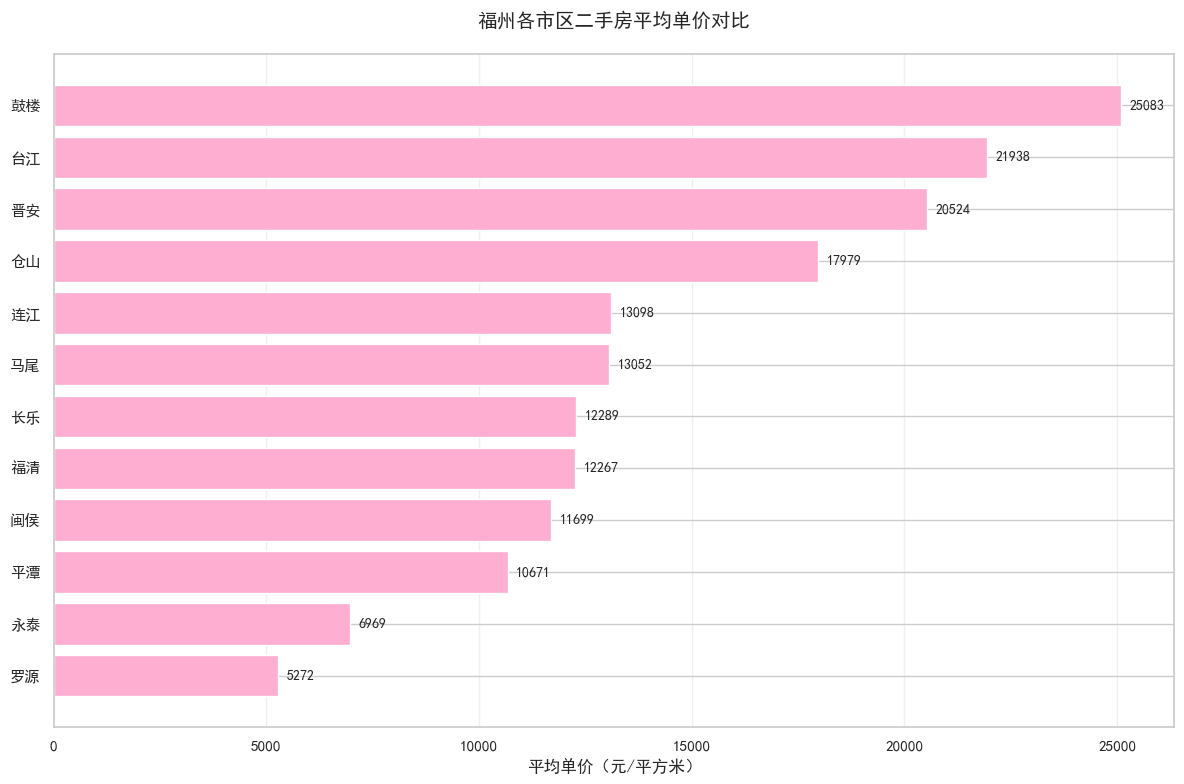

In [15]:
#代码：绘制区域均价横向柱状图
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 准备数据
price_data = pd.Series({
    '鼓楼': 25083, '台江': 21938, '晋安': 20524, '仓山': 17979,
    '连江': 13098, '马尾': 13052, '长乐': 12289, '福清': 12267,
    '闽侯': 11699, '平潭': 10671, '永泰': 6969, '罗源': 5272
}).sort_values(ascending=True)

# 绘制横向条形图
plt.figure(figsize=(12, 8))

bars = plt.barh(price_data.index, price_data.values, color="#fdaed1")

# 添加标题与坐标轴
plt.title('福州各市区二手房平均单价对比', fontsize=14, pad=20)
plt.xlabel('平均单价（元/平方米）', fontsize=12)

# 条形末端标注数值
for bar in bars:
    w = bar.get_width()
    plt.text(w + 200, bar.get_y() + bar.get_height()/2,
             f'{int(w)}', va='center', fontsize=10)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**图表分析：**
- **房价梯度清晰**：鼓楼区以25083元/㎡领跑全市，台江、晋安紧随其后，核心三区单价均突破2万元/㎡；远郊区域单价逐级下探，罗源、永泰不足7000元/㎡，形成“核心主城 — 近郊 — 远郊”三级房价梯队。
- **地段溢价显著**：核心老城区依托配套优势单价领先，外围区县受地理位置影响，房价与主城差距明显，区域分化特征突出。

### 图表 2：福州二手房总价分布特征
**分析问题：** 福州二手房的整体价格分布是怎样的？主流总价区间是多少？

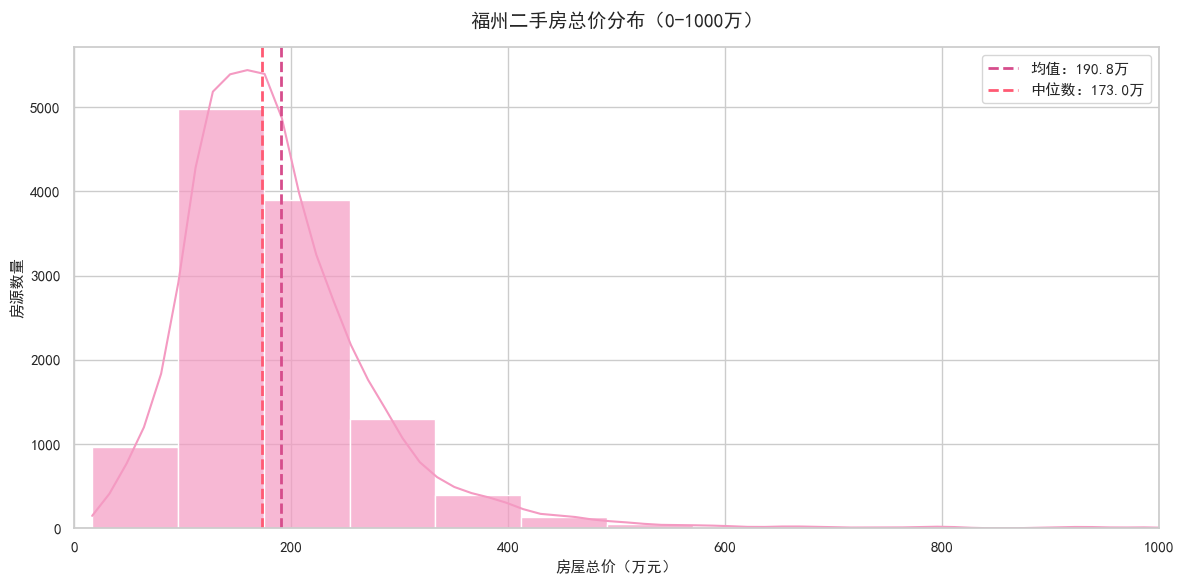

In [16]:
#绘制总价分布直方图
plt.figure(figsize=(12, 6))

# 绘制直方图+核密度曲线，限定x轴范围，突出主流区间
sns.histplot(data=data, x='总价数值', kde=True, bins=40, color='#f49ac2', alpha=0.7)
plt.xlim(0, 1000)

# 添加均值、中位数参考线
mean_price = data['总价数值'].mean()
median_price = data['总价数值'].median()
plt.axvline(mean_price, color='#d64d8c', linestyle='--', linewidth=2, label=f'均值：{mean_price:.1f}万')
plt.axvline(median_price, color="#ff5a73", linestyle='--', linewidth=2, label=f'中位数：{median_price:.1f}万')

plt.title('福州二手房总价分布（0-1000万）', fontsize=14, pad=15)
plt.xlabel('房屋总价（万元）', fontsize=11)
plt.ylabel('房源数量', fontsize=11)
plt.legend()
plt.tight_layout()
plt.show()

**图表分析：**
- **分布右偏明显：** 总价整体呈右偏分布，平均总价 190.8 万元高于中位数 173.0 万元，少量高端房源拉高了整体均值。
- **主流区间集中：** 房源总价峰值集中在 130-225 万元，是市场刚需刚改主力区间；300 万以上房源占比快速下降，高端市场体量有限。

### 图表 3：房屋面积与总价的相关性
**分析问题：** 房屋面积与总价之间是否存在明显的线性关系？面积对价格的影响程度如何？

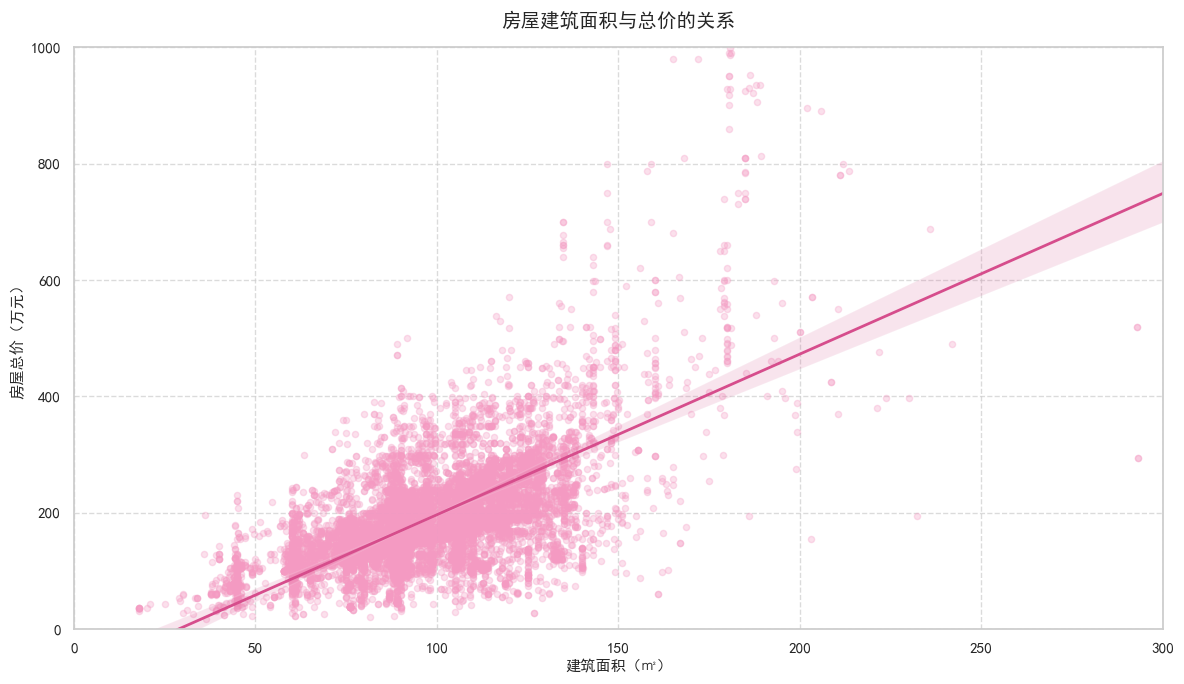

房屋面积与总价的皮尔逊相关系数为：0.643


In [17]:
#绘制面积-总价散点图
plt.figure(figsize=(12, 7))

# 绘制散点图+回归线，限定轴范围，突出核心分布
sns.regplot(data=data, x='面积数值', y='总价数值', 
            scatter_kws={'alpha':0.3, 'color':'#f49ac2', 's':20}, 
            line_kws={'color':'#d64d8c', 'linewidth':2})
plt.xlim(0, 300)
plt.ylim(0, 1000)

plt.title('房屋建筑面积与总价的关系', fontsize=14, pad=15)
plt.xlabel('建筑面积（㎡）', fontsize=11)
plt.ylabel('房屋总价（万元）', fontsize=11)
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 计算皮尔逊相关系数
corr = data['面积数值'].corr(data['总价数值'])
print(f'房屋面积与总价的皮尔逊相关系数为：{corr:.3f}')

**图表分析:**
- **强正线性相关：** 面积与总价呈极强的正相关关系，建筑面积越大，房屋总价整体越高，是影响房价的最核心因素。
- **价差受多因素影响：** 同面积房源总价存在明显跨度，说明除面积外，区位、房龄、配套等因素也会对价格产生显著影响。

### 图表 4：不同户型房源供给占比
**分析问题：** 福州二手房市场的供给结构如何？哪种户型的挂牌量最高？

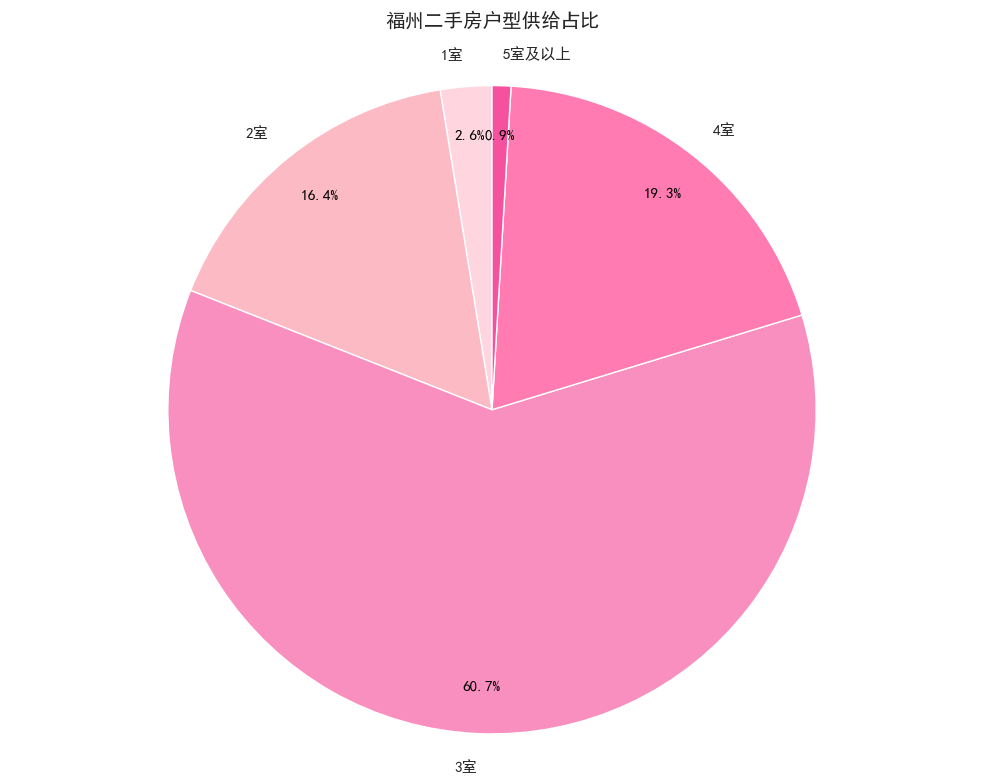

In [18]:
#绘制户型分布饼图
plt.figure(figsize=(10, 8))

# 统计各室数房源，合并小占比类别优化饼图观感
room_count = data['室数'].value_counts().sort_index()
# 合并5室及以上的小众户型
other_count = room_count[room_count.index >= 5].sum()
room_merged = room_count[room_count.index < 5]
room_merged['5室及以上'] = other_count

colors = ['#ffd6e0', "#fcbac4", "#f98fbf", "#ff7bb2", "#f6519e"]

# 绘制饼图，显示占比数值
wedges, texts, autotexts = plt.pie(
    room_merged.values,
    labels=[f'{i}室' if i != '5室及以上' else i for i in room_merged.index],
    autopct='%.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.85,
    textprops={'fontsize': 11}
)

# 百分比文字设为白色，提升可读性
for autotext in autotexts:
    autotext.set_color('black')

plt.title('福州二手房户型供给占比', fontsize=14, pad=20)
plt.axis('equal')  # 保证饼图为正圆形
plt.tight_layout()
plt.show()

**图表分析:**
- **刚需户型主导**：3室房源占比达60.7%，是市场绝对供给主力，匹配主流家庭的刚需刚改需求。
- **供给结构集中**：2室、4室合计占比约35%，1室与5室及以上户型占比不足4%，市场供给高度围绕主流居住需求布局。

### 图表 5：不同房龄房源平均单价对比
**分析问题：** 房龄对二手房价格有何影响？次新房是否存在明显的价格溢价？

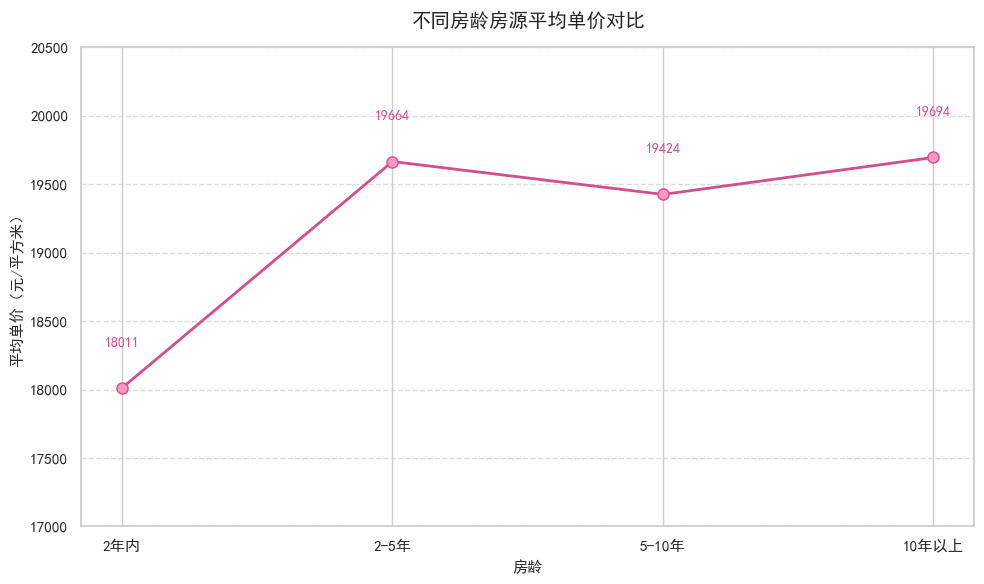

In [19]:
#绘制房龄 - 单价折线图
plt.figure(figsize=(10, 6))

# 按房龄逻辑顺序排序
age_order = ['2年内', '2-5年', '5-10年', '10年以上']
age_price = data.groupby('房龄')['均价数值'].mean().reindex(age_order)

# 绘制折线图，添加数据点，保持粉色系风格
plt.plot(age_price.index, age_price.values, color='#d64d8c', marker='o', 
         linewidth=2, markersize=8, markerfacecolor='#f49ac2', markeredgecolor='#d64d8c')

# 每个数据点标注具体单价
for x, y in zip(age_price.index, age_price.values):
    plt.text(x, y + 300, f'{int(y)}', ha='center', fontsize=10, color='#d64d8c')

plt.title('不同房龄房源平均单价对比', fontsize=14, pad=15)
plt.xlabel('房龄', fontsize=11)
plt.ylabel('平均单价（元/平方米）', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(17000, 20500)  # 收窄y轴范围，放大价格差异
plt.tight_layout()
plt.show()

**图表分析:**
- **无明显房龄溢价**：次新房未呈现价格优势，2年内房源单价为全段最低；老房单价反而更高，房龄与价格未呈常规负相关。
- **地段影响主导**：老旧房源多集中在核心主城区，地段溢价抵消了房龄折价；新建次新房多分布在外围板块，拉低了整体均价。

## 8. 主要结论
本次分析基于福州全市超1.18万套二手房挂牌样本，围绕供给结构、价格分布、核心影响因素三大维度展开统计分析，核心研究发现与说明如下：

#### 一、核心研究发现
1. **供给结构：刚需刚改主导，区域与户型双集中**
市场供给高度向主城核心区与主流居住产品倾斜：晋安区、仓山区合计贡献近7成挂牌房源，是二手房流通最活跃的板块；户型端3室房源占比达60.7%，60-120㎡面积段合计占比近8成，刚需与刚改产品是市场绝对主力。1室小户型、5室以上大户型供给占比合计不足4%，小众产品稀缺性较强。

2. **价格特征：圈层梯度清晰，整体呈右偏分布**
房价呈现鲜明的“核心主城—近郊—远郊”三级递减梯队：鼓楼区以25083元/㎡领跑全市，核心三区单价均突破2万元/㎡；远郊罗源、永泰单价不足7000元/㎡，区域价差悬殊，分化特征突出。总价层面整体呈右偏分布，市场主流总价集中在130-225万元，匹配大众购房预算；少量高端豪宅房源拉高了整体均值，形成明显的长尾效应。

3. **价格驱动：面积为核心变量，地段权重高于房龄**
建筑面积与房屋总价呈极强正线性相关，是决定房价的最核心、最直接因素；同面积段内的价格差异，主要来源于区位、配套等外部条件。
与常规认知不同，全市维度下次新房并未呈现价格溢价，2年内房源单价反而为全段最低。核心原因是老旧房源多集中于鼓楼、台江等核心主城区，成熟配套带来的地段溢价完全抵消了房龄折价，说明在福州二手房市场，地段对房价的影响权重显著高于房龄本身。

#### 二、数据局限与结论说明
1. **价格属性局限**：本次分析全部基于挂牌报价，与实际成交价普遍存在议价空间，结论仅反映市场挂牌预期与业主报价水平，不能完全等同于真实成交价格走势。
2. **样本分布局限**：样本高度集中于晋安、仓山等主城区，永泰、罗源、平潭等远郊区域样本量不足百套，远郊市场的统计结果代表性较弱，相关结论仅作趋势参考。
3. **影响维度局限**：分析未纳入楼层、装修品质、学区属性、物业水平等细分价格影响因子，对同区域、同户型下的价格分化解释力度有限，后续可补充维度深化研究。
4. **极端值干扰说明**：少量千万级豪宅、超大户型样本对整体均值存在一定抬升作用，该类高端细分市场的规律不适用于大众刚需市场，需区分场景看待。